<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ed/Pandas_logo.svg/1200px-Pandas_logo.svg.png" width="25%" height="25%" />

# Pandas - Topic 16 - Pandas Data Visualisation Part 1

## <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%202%20-%20Unit%20Objective.png"> Topic Objectives

* Visualise data with Pandas built-in capabilities, using line plot, histogram and box plot

---

## <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png"> Import Packages for Learning

In [ ]:
import numpy as np
import pandas as pd

---

## <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> Pandas Data Visualisation Part 1

### Disclaimer and imports

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> **You will only start understanding your data objectively when you start visualising it**
* Pandas' has built-in methods/functions for visualising data that will help you to understand your data better.
  * Even though it is related to Pandas, we need to import matplotlib, which we will study in more detail later in the course. For now, you just need to be aware of it.
* Pandas' capabilities/flexibilities for plotting can not be compared to Matplotlib, Seaborn or Plotly. 
  * You typically use Pandas plotting capabilities for quick visualisations. For more elaborate visualisations, we will cover other libraries later in the course

In [ ]:
import matplotlib.pyplot as plt

### <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> .plot()

You can use `.plot()` to visualise data in Pandas. The documentation is [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html)
* A relevant argument is `'kind'`, where you determine the kind of plot to produce. The options include:

  * 'line': line plot (default)
  * 'bar': vertical bar plot
  * 'barh': horizontal bar plot
  * 'hist': histogram
  * 'box': boxplot
  * 'kde': Kernel Density Estimation plot
  * 'area': area plot
  * 'pie': pie plot
  * 'scatter': scatter plot



To choose an appropriate argument for `kind` in this function requires an understanding of data types and how to visualise data. Experience gained through data projects will help with this.
  * We will start exploring  the plots and present additional arguments

---

For the next set of exercises, we will use datasets from Seaborn

In [ ]:
import seaborn as sns
sns.get_dataset_names()

---

### <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> Line Plot

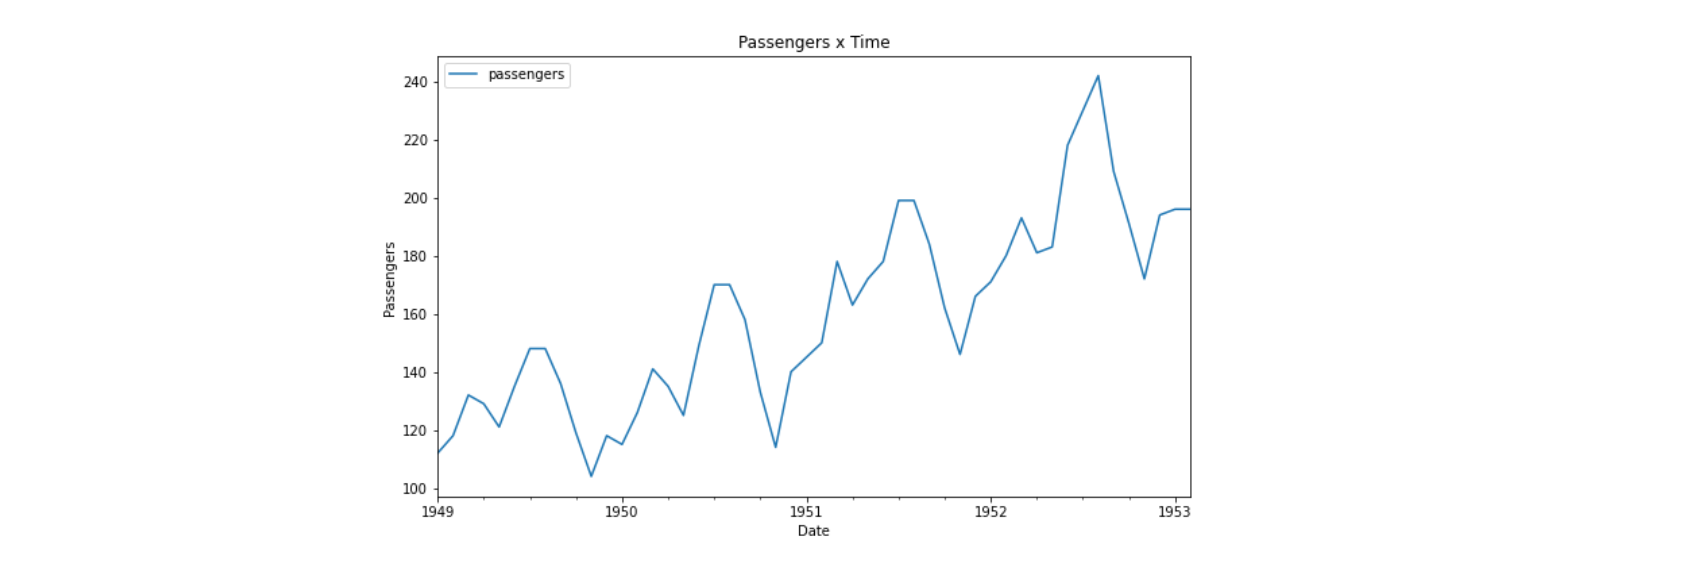

A line chart is used to present data change over time. Let's consider the 'flights' dataset. 

In [ ]:
df = sns.load_dataset('flights')
df = df.head(50)
print(df.shape)
df.head()

We need to process the data for this exercise
  * First, we transform year and month to string using `.astype()`
  * Then we combine the strings in the pattern:  month - year, so that we can convert this pattern to date with `pd.to_datetime()`
  * We finally set Date as index with `.set_index()`

In [ ]:
df['year'] = df['year'].astype('str')
df['month'] = df['month'].astype('str')
df['Date'] = pd.to_datetime(df['month'] + '-' + df['year'] )
df.set_index('Date',inplace=True)
df.head()

We are interested in producing a **line plot** where y values are passengers, and x values are Date.
  * By default, x is the index. In case you want another variable, you can specify it.
  * figsize is a tuple to set plot height, and width
  * xlabel is x-axis label
  * ylabel is y-axis label
  * title is plot title.

* **plt.show()**
  * `plt.show()` gives the command to plot.

In [ ]:
df.plot(kind='line',y='passengers',
        figsize=(10,6),
        title='Passengers x Time', xlabel='Date', ylabel='Passengers'
        )
plt.show()

You can process the data and look for the average levels over the years
  * We first groupby year, set `as_index=False`
  * Then aggregate and create AvgLevels as the mean of passengers
  * Finally, we create a line plot, indicating x and y. We just used one argument here: figsize

* We notice a trend that passengers' levels increased over time.
  * We can't state definitively that the levels increased simply by plotting. We need statistical tests for that, which we will learn in future lessons. This plot just helps to see a trend over the years and that the trend is upwards.

In [ ]:
(df
 .groupby(by=['year'],as_index=False)
 .agg(AvgLevels=('passengers','mean'))
 .plot(kind='line',x='year',y='AvgLevels', figsize=(5,5))
 )
plt.show()

You can plot multiple lines in your line plot
  * We create Col1 as an expression made with NumPy
  * This variable doesn't have any particular business meaning; it is just for teaching purposes

In [ ]:
df['Col1'] = 300 + 20 * np.random.randn(df.shape[0]) + np.random.randint(low=-10, high=20, size=df.shape[0])
df.head()

We plot the dataset using `.plot(),` `kind='line'`
  * we parse a list for y, containing passengers and Col1

In [ ]:
df.plot(kind='line',y=['passengers','Col1'],
        figsize=(10,6),
        title='Passengers and Col1 x Time', xlabel='Date', ylabel=' '
        )
plt.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> **PRACTICE**: We will use the data set of different types of cars across the America market to create a bar chart.


In [ ]:
df_practice = pd.read_csv("CarPrice_Assignment.csv")
df_practice

You are interested in using a bar chart to analyse the price by fuel type (gas vs diesel).

On the DataFrame df_practice, you should do a 
* groupby by fueltype
* then aggregate and create `AvgPrice` as the mean of `price`
* Then use plot setting kind to bar and ylabel to AvgPrice and use figsize with 10,5

In [ ]:
# Write your code here.


At the end, your plot should look like this

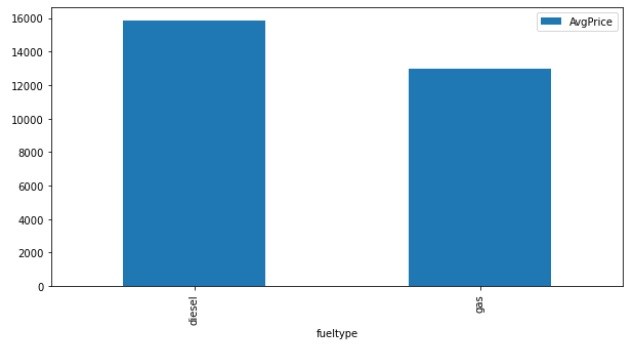

---